# CNNs on the Road — and at Rutgers
**CS 461 · Instructor reference · 60-minute recitation**

Build a CNN, calculate its tensor shapes and parameter counts, train it to predict a steering-wheel angle,
and implement VisualBackProp to visualize its feature responses.

**Two coding exercises:** (1) CNN, (2) VisualBackProp. Both solutions are complete here.
Allow about 20 minutes for explanation, 30 minutes for student coding, and 10 minutes for discussion.
The data, training loop, and plotting code are provided. This notebook uses one fixed recipe selected
during instructor preparation; students do not run a hyperparameter comparison.

## 1. Setup and driving data
Run cells in order. Use the supplied `sullychen_road_61x125.npz` in `data/` or next to this notebook.
Colab: select a GPU runtime if available; keep its preinstalled PyTorch. Campus images are downloaded once.

In [1]:
import base64
import copy
import io
import os
import time
import urllib.request
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps
from IPython.display import Image as DisplayImage, display

SEED, EPOCHS, BATCH_SIZE, LEARNING_RATE = 461, 17, 64, 1e-3
L2_LAMBDA = 0.0001  # fixed in instructor preparation using validation only
RECIPE_NAME = 'road_crop + augmentation + L2'
IMG_H, IMG_W = 61, 125
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(min(2, os.cpu_count() or 1))
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if (
        hasattr(torch.backends, 'mps')
        and torch.backends.mps.is_available()
    )
    else 'cpu'
)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print(f'PyTorch {torch.__version__} | device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name())

Matplotlib is building the font cache; this may take a moment.


PyTorch 2.14.0 | device: mps


**Data:** a classroom subset of [Sully Chen's driving dataset](https://github.com/SullyChen/driving-datasets)
([MIT license](https://github.com/SullyChen/driving-datasets/blob/master/LICENSE)). Keep ordinary steering angles (|angle| ≤ 60°),
crop the original 455 × 256 images to `(0, 120, 455, 256)`, grayscale, and resize to **61 × 125**.

The archive provides **8,770 train / 1,305 validation / 1,350 test** examples. Training uses every third source frame;
validation/test retain their original every-sixth-frame samples. Entire validation/test road intervals and a 30-frame
buffer are excluded from training. Normalize with **training-only** mean/std; targets are `angle / 60`.
This is a temporal holdout from one driving sequence; the test examples were inspected during prior lesson preparation.

Train: X (8770, 1, 61, 125), y (8770,)
Validation: X (1305, 1, 61, 125), y (1305,)
Test: X (1350, 1, 61, 125), y (1350,)
Train-only mean = 0.4130, std = 0.1923
Batch size = 64; final training batch has 2 examples.


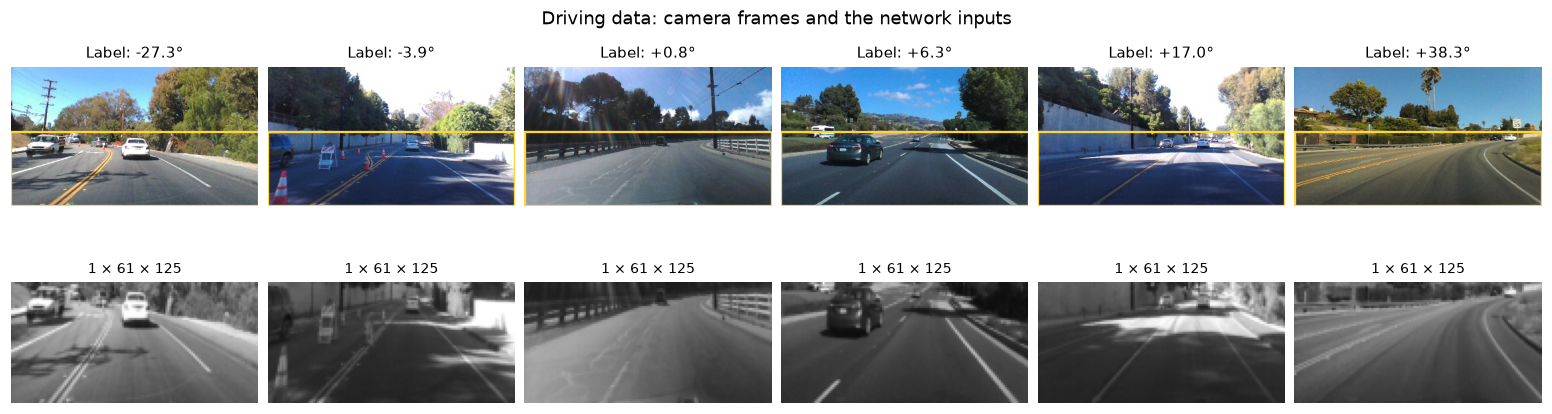

In [2]:
filename = 'sullychen_road_61x125.npz'
candidates = [Path('data') / filename, Path(filename),
              Path('Recitation_inRecitationAssignment1/data') / filename]
DATA_PATH = next((p for p in candidates if p.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'Upload {filename} beside the notebook, or put it in data/.')
with np.load(DATA_PATH, allow_pickle=False) as archive:
    data = {name: archive[name] for name in archive.files}

frames = data['frame'].astype(np.int64)
assert np.all(np.diff(frames) > 0)
train_np, val_np, test_np = [data['split'] == label for label in (0, 1, 2)]
is_train, is_val, is_test = [torch.from_numpy(m) for m in (train_np, val_np, test_np)]
assert [int(m.sum()) for m in (is_train, is_val, is_test)] == [8770, 1305, 1350]
assert not ((is_train & is_val) | (is_train & is_test) | (is_val & is_test)).any()
for lo, hi, _ in data['heldout_intervals']:
    assert not ((frames[train_np] >= lo-30) & (frames[train_np] <= hi+30)).any()

images = torch.from_numpy(data['X']).float().unsqueeze(1) / 255.0
targets = torch.from_numpy(data['angle']).float() / 60.0
train_mean = images[is_train].mean()
train_std = images[is_train].std().clamp_min(1e-8)
X_train, X_val, X_test = [(images[m]-train_mean)/train_std for m in (is_train,is_val,is_test)]
y_train, y_val, y_test = [targets[m] for m in (is_train,is_val,is_test)]
train_set = TensorDataset(images[is_train],y_train)  # raw pixels for train-only augmentation
train_eval_set = TensorDataset(X_train,y_train)
val_set = TensorDataset(X_val,y_val)
test_set = TensorDataset(X_test,y_test)
loader_options = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=device.type == 'cuda')
train_eval_loader = DataLoader(train_eval_set, shuffle=False, **loader_options)
val_loader = DataLoader(val_set, shuffle=False, **loader_options)
test_loader = DataLoader(test_set, shuffle=False, **loader_options)
for name,x,y in [('Train',X_train,y_train),('Validation',X_val,y_val),('Test',X_test,y_test)]:
    print(f'{name}: X {tuple(x.shape)}, y {tuple(y.shape)}')
print(f'Train-only mean = {train_mean:.4f}, std = {train_std:.4f}')
print(f'Batch size = {BATCH_SIZE}; final training batch has {len(train_set) % BATCH_SIZE} examples.')

# These six examples were chosen during dataset preparation, not by inspecting our model's masks.
example_indices = data['raw_pos'].astype(int)
assert bool(is_test[example_indices].all())
example_raw = images[example_indices]
example_x = (example_raw - train_mean) / train_std
example_angles = data['angle'][example_indices]
fig, axes = plt.subplots(2, 6, figsize=(14, 4), layout='constrained')
x0, y0, x1, y1 = data['crop']
for col, (raw, inp, angle) in enumerate(zip(data['raw'], example_raw, example_angles)):
    axes[0, col].imshow(raw)
    axes[0, col].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec='#ffd43b', lw=1.5))
    axes[0, col].set_title(f'Label: {angle:+.1f}°', fontsize=10)
    axes[1, col].imshow(inp[0], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title('1 × 61 × 125', fontsize=9)
    for ax in axes[:, col]:
        ax.axis('off')
fig.suptitle('Driving data: camera frames and the network inputs')
plt.show()

## 2. Exercise 1 — Implement the CNN (reference solution)
Use six explicit `Conv2d` layers, each followed by ReLU, then the fully connected head.
No pooling or batch normalization. `B` is the current batch size, not a channel count or a learned parameter.

For `groups=1`, dilation 1, and one spatial dimension at a time:

$$W=K_hK_wC_{in}C_{out},\quad b=C_{out},\qquad
O=\left\lfloor\frac{N+2P-K}{S}\right\rfloor+1.$$
$$r_0=j_0=1,\qquad r_l=r_{l-1}+(K_l-1)j_{l-1},\qquad j_l=j_{l-1}S_l.$$

Here $r$ is the **theoretical receptive-field size** and $j$ is the spacing between neighboring units in input pixels.
The input image size and batch size do not change a convolution's parameter count.
Sources: [PyTorch Conv2d: Shape / Variables](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html);
[Araujo et al.: Computing receptive field size](https://distill.pub/2019/computing-receptive-fields/#computing-receptive-field-size).

**Hand-calculation reference:** `K=3, P=0` for every convolution; spatial values are height × width.

| Layer | S | Output shape | Weights | Biases | RF | Jump |
|---|---:|---|---:|---:|---|---:|
| Input | — | `(B,1,61,125)` | — | — | 1 × 1 | 1 |
| Conv1 + ReLU | 1 | `(B,16,59,123)` | 144 | 16 | 3 × 3 | 1 |
| Conv2 + ReLU | 2 | `(B,16,29,61)` | 2,304 | 16 | 5 × 5 | 2 |
| Conv3 + ReLU | 1 | `(B,24,27,59)` | 3,456 | 24 | 9 × 9 | 2 |
| Conv4 + ReLU | 2 | `(B,24,13,29)` | 5,184 | 24 | 13 × 13 | 4 |
| Conv5 + ReLU | 1 | `(B,32,11,27)` | 6,912 | 32 | 21 × 21 | 4 |
| Conv6 + ReLU | 2 | `(B,32,5,13)` | 9,216 | 32 | 29 × 29 | 8 |
| Flatten | — | `(B,2080)` | 0 | 0 | — | — |
| Linear + ReLU | — | `(B,64)` | 133,120 | 64 | — | — |
| Linear | — | `(B,1)` | 64 | 1 | — | — |
| Squeeze last axis | — | `(B,)` | 0 | 0 | — | — |

Convolution parameters: **27,360**. Total learned parameters: **160,609**.
The head combines all final spatial positions; 29 × 29 describes **one Conv6 unit**, not the final prediction.

In [3]:
# Exercise 1 — complete instructor solution.
class MiniNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0, bias=True)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=0, bias=True)
        self.conv3 = nn.Conv2d(16, 24, kernel_size=3, stride=1, padding=0, bias=True)
        self.conv4 = nn.Conv2d(24, 24, kernel_size=3, stride=2, padding=0, bias=True)
        self.conv5 = nn.Conv2d(24, 32, kernel_size=3, stride=1, padding=0, bias=True)
        self.conv6 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=0, bias=True)
        self.flatten = nn.Flatten(start_dim=1)  # preserve the batch axis
        self.fc1 = nn.Linear(32 * 5 * 13, 64)
        self.fc2 = nn.Linear(64, 1)

    @property
    def convs(self):
        return (self.conv1, self.conv2, self.conv3, self.conv4, self.conv5, self.conv6)

    def forward(self, x, return_maps=False):
        a1 = F.relu(self.conv1(x))    # (B, 16, 59, 123)
        a2 = F.relu(self.conv2(a1))   # (B, 16, 29, 61)
        a3 = F.relu(self.conv3(a2))   # (B, 24, 27, 59)
        a4 = F.relu(self.conv4(a3))   # (B, 24, 13, 29)
        a5 = F.relu(self.conv5(a4))   # (B, 32, 11, 27)
        a6 = F.relu(self.conv6(a5))   # (B, 32, 5, 13)
        flat = self.flatten(a6)      # (B, 2080)
        hidden = F.relu(self.fc1(flat))  # (B, 64)
        prediction = self.fc2(hidden).squeeze(-1)  # (B,), even when B = 1
        return (prediction, [a1, a2, a3, a4, a5, a6]) if return_maps else prediction

In [4]:
# Verify the hand calculations with actual tensors.
expected_shapes = [(16,59,123), (16,29,61), (24,27,59), (24,13,29), (32,11,27), (32,5,13)]
expected_counts = [(144,16), (2304,16), (3456,24), (5184,24), (6912,32), (9216,32)]
probe = MiniNet()
with torch.no_grad():
    for batch in (1, BATCH_SIZE):
        prediction, maps = probe(torch.zeros(batch, 1, IMG_H, IMG_W), return_maps=True)
        assert prediction.shape == (batch,)
        assert [tuple(f.shape[1:]) for f in maps] == expected_shapes

h, w, rf, jump = IMG_H, IMG_W, 1, 1
print(f'{"Layer":<8} {"Output C,H,W":<18} {"Weights":>8} {"Biases":>7} {"RF":>5} {"Jump":>6}')
for i, (conv, expected) in enumerate(zip(probe.convs, expected_counts), 1):
    k, s = conv.kernel_size[0], conv.stride[0]
    h, w = (h-k)//s+1, (w-k)//s+1
    rf, jump = rf + (k-1)*jump, jump*s
    assert (conv.weight.numel(), conv.bias.numel()) == expected
    print(f'{i:<8} {str((conv.out_channels,h,w)):<18} {expected[0]:>8,} {expected[1]:>7} {rf:>5} {jump:>6}')
assert (h, w, rf, jump) == (5, 13, 29, 8)
assert sum(p.numel() for c in probe.convs for p in c.parameters()) == 27360
assert sum(p.numel() for p in probe.parameters()) == 160609
print('PASS: shapes, weights, biases, receptive fields, and 160,609 total parameters.')
del probe

Layer    Output C,H,W        Weights  Biases    RF   Jump
1        (16, 59, 123)           144      16     3      1
2        (16, 29, 61)          2,304      16     5      2
3        (24, 27, 59)          3,456      24     9      2
4        (24, 13, 29)          5,184      24    13      4
5        (32, 11, 27)          6,912      32    21      4
6        (32, 5, 13)           9,216      32    29      8
PASS: shapes, weights, biases, receptive fields, and 160,609 total parameters.


## 3. Train one fixed recipe (provided)
**Recipe:** six-layer CNN, L2 on weights (`lambda = 1e-4`), Adam (`lr = 0.001`), batch size 64,
seed 461, **17 epochs**. The data recipe was chosen during instructor preparation, not during class.

For training only: random horizontal flip **with the angle sign reversed**, mild brightness/contrast/gamma changes,
and small Gaussian noise. Validation and test images remain unaugmented. The provided code below handles this.
Train/validation curves show pure MSE; select the lowest-validation-MSE checkpoint and evaluate test once.
The objective is $\mathrm{MSE}+\frac{\lambda}{2}\sum_{W}\lVert W\rVert_2^2$; biases are excluded.
[L2 regularization](https://cs231n.github.io/neural-networks-2/#reg).

In [5]:
def augment_training_batch(x, y):
    # x is raw grayscale in [0,1]. Preserve steering under photometric changes.
    flip = torch.rand(len(x), device=x.device) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(-1), x)
    y = torch.where(flip, -y, y)
    shape = (len(x), 1, 1, 1)
    gamma = 0.7 + 0.6 * torch.rand(shape, device=x.device)
    gain = 0.7 + 0.6 * torch.rand(shape, device=x.device)
    offset = (torch.rand(shape, device=x.device) - 0.5) * 0.2
    x = (x.clamp_min(1e-6).pow(gamma) * gain + offset + 0.01 * torch.randn_like(x)).clamp(0, 1)
    return (x - train_mean.to(x.device)) / train_std.to(x.device), y

@torch.no_grad()
def evaluate_mse(model, loader):
    model.eval()
    squared_error, count = 0.0, 0
    for xb,yb in loader:
        xb,yb = xb.to(device),yb.to(device)
        squared_error += F.mse_loss(model(xb),yb,reduction='sum').item()
        count += yb.numel()
    return squared_error / count

def synchronize_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()

torch.manual_seed(SEED)
model = MiniNet().to(device)
untrained_model = copy.deepcopy(model).eval()
train_loader = DataLoader(train_set,shuffle=True,
                          generator=torch.Generator().manual_seed(SEED),**loader_options)
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
regularized_weights = [p for p in model.parameters() if p.ndim > 1]
history = {'epoch':[0], 'train':[evaluate_mse(model,train_eval_loader)],
           'val':[evaluate_mse(model,val_loader)]}
best_epoch, best_val_mse = 0, history['val'][0]
best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
zero_val_mse = y_val.square().mean().item()
print(f'Epoch 0 | train MSE {history["train"][0]:.5f} | val MSE {best_val_mse:.5f}')
synchronize_device()
start = time.perf_counter()
for epoch in range(1,EPOCHS+1):
    model.train()
    for xb,yb in train_loader:
        xb,yb = augment_training_batch(xb.to(device),yb.to(device))
        optimizer.zero_grad(set_to_none=True)
        loss = F.mse_loss(model(xb),yb)
        if L2_LAMBDA:
            loss = loss + L2_LAMBDA/2 * sum(w.square().sum() for w in regularized_weights)
        loss.backward()
        optimizer.step()
    train_mse = evaluate_mse(model,train_eval_loader)
    val_mse = evaluate_mse(model,val_loader)
    history['epoch'].append(epoch)
    history['train'].append(train_mse)
    history['val'].append(val_mse)
    if val_mse < best_val_mse:
        best_epoch,best_val_mse = epoch,val_mse
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    synchronize_device()
    print(f'Epoch {epoch} | train MSE {train_mse:.5f} | val MSE {val_mse:.5f} '
          f'| elapsed {time.perf_counter()-start:.1f}s')
synchronize_device()
training_seconds = time.perf_counter()-start
model.load_state_dict(best_state)
model.eval()
optimizer.zero_grad(set_to_none=True)
# Test is first evaluated here, after all training/checkpoint decisions are complete.
test_mse = evaluate_mse(model,test_loader)
zero_test_mse = y_test.square().mean().item()
print(f'Restored epoch {best_epoch}: validation MSE {best_val_mse:.5f}')
print(f'Final test MSE {test_mse:.5f} | zero-prediction test baseline {zero_test_mse:.5f}')
print(f'{EPOCHS} epochs + train/validation evaluations: {training_seconds:.1f}s on {device}')

Epoch 0 | train MSE 0.07991 | val MSE 0.09142


Epoch 1 | train MSE 0.05372 | val MSE 0.06511 | elapsed 3.5s


Epoch 2 | train MSE 0.04057 | val MSE 0.04498 | elapsed 6.9s


Epoch 3 | train MSE 0.03073 | val MSE 0.03816 | elapsed 10.3s


Epoch 4 | train MSE 0.02399 | val MSE 0.02910 | elapsed 13.8s


...

Epoch 13 | train MSE 0.01219 | val MSE 0.01987 | elapsed 42.0s


Epoch 14 | train MSE 0.01027 | val MSE 0.01952 | elapsed 45.0s


Epoch 15 | train MSE 0.01022 | val MSE 0.02342 | elapsed 48.2s


Epoch 16 | train MSE 0.00903 | val MSE 0.02111 | elapsed 51.4s


Epoch 17 | train MSE 0.00794 | val MSE 0.01921 | elapsed 54.5s
Restored epoch 17: validation MSE 0.01921
Final test MSE 0.04015 | zero-prediction test baseline 0.07657
17 epochs + train/validation evaluations: 54.5s on mps


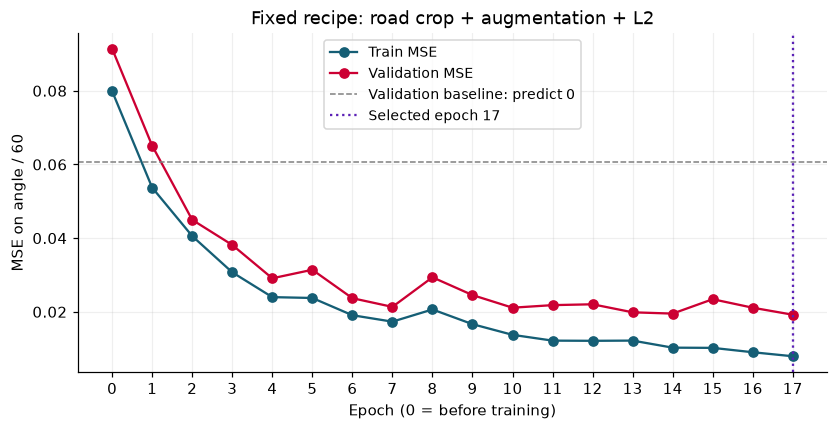

In [6]:
fig,ax = plt.subplots(figsize=(7.5,3.8),layout='constrained')
ax.plot(history['epoch'],history['train'],'o-',label='Train MSE',color='#155e75')
ax.plot(history['epoch'],history['val'],'o-',label='Validation MSE',color='#cc0033')
ax.axhline(zero_val_mse,color='gray',ls='--',lw=1,label='Validation baseline: predict 0')
ax.axvline(best_epoch,color='#5b21b6',ls=':',lw=1.5,label=f'Selected epoch {best_epoch}')
ax.set(xlabel='Epoch (0 = before training)',ylabel='MSE on angle / 60',
       title=f'Fixed recipe: {RECIPE_NAME.replace("_", " ")}',xticks=history['epoch'])
ax.legend(fontsize=9)
ax.grid(alpha=.2)
plt.show()

### Try two familiar places: Rutgers
These campus images have no steering-angle labels and do not enter test loss; a model output is not a known correct steering instruction.

- **George Street / Downtown New Brunswick** — Tomwsulcer, Wikimedia Commons, [CC0 1.0](https://creativecommons.org/publicdomain/zero/1.0/).
  [Source page](https://commons.wikimedia.org/wiki/File:Rutgers_University_New_Brunswick_downtown_George_Street_view_street_scene.jpg) ·
  [Original image](https://upload.wikimedia.org/wikipedia/commons/1/13/Rutgers_University_New_Brunswick_downtown_George_Street_view_street_scene.jpg).
- **Rutgers Business School / Livingston Campus** — image source: Rutgers Business School.
  [Livingston Campus Highlights](https://www.business.rutgers.edu/visit/livingston-highlights) ·
  [Original image](https://www.business.rutgers.edu/sites/default/files/styles/full_size_content_image_780x400_/public/images/content/Rutgers-Business-School-Livingston-Campus-Back.jpg.jpg?itok=tlGHegSI).

For both: remove the top 120/256 of the image, grayscale, resize to 61 × 125, then apply the **training** mean/std.
The yellow box shows the retained region. Displayed model inputs are cropped, grayscaled, and resized versions of the cited photos.

In [7]:
#@title Supporting code: load and preprocess the two campus photos
CAMPUS_SOURCES = [
    dict(name='George Street', filename='george_street.jpg',
         url='https://upload.wikimedia.org/wikipedia/commons/1/13/Rutgers_University_New_Brunswick_downtown_George_Street_view_street_scene.jpg'),
    dict(name='Livingston / Rutgers Business School', filename='livingston_rbs.jpg',
         url='https://www.business.rutgers.edu/sites/default/files/styles/full_size_content_image_780x400_/public/images/content/Rutgers-Business-School-Livingston-Campus-Back.jpg.jpg?itok=tlGHegSI'),
]
CAMPUS_DIR = DATA_PATH.parent / 'campus'

def load_campus_photo(source):
    path = CAMPUS_DIR / source['filename']
    uploaded = Path(source['filename'])
    if not path.is_file() and uploaded.is_file():
        path = uploaded
    if not path.is_file():
        try:
            request = urllib.request.Request(source['url'], headers={
                'User-Agent': 'Rutgers-CNN-Teaching-Lab/1.0 (educational image attribution demo)'})
            with urllib.request.urlopen(request, timeout=40) as response:
                payload = response.read()
            with Image.open(io.BytesIO(payload)) as downloaded:
                downloaded.verify()
            path.parent.mkdir(parents=True, exist_ok=True)
            path.write_bytes(payload)
            print(f'Downloaded {source["filename"]}')
        except Exception as err:
            raise RuntimeError(f'Could not download {source["name"]}. Save the linked original '
                               f'as {source["filename"]} beside the notebook and rerun this cell.') from err
    else:
        print(f'Using local {path}')
    with Image.open(path) as original:
        return ImageOps.exif_transpose(original).convert('RGB')

def preprocess_campus_photo(image):
    width, height = image.size
    top = int(round(height * 120 / 256))
    crop_box = (0, top, width, height)
    gray = image.convert('L').crop(crop_box).resize((IMG_W, IMG_H), Image.Resampling.BILINEAR)
    raw_tensor = torch.from_numpy(np.array(gray, dtype=np.float32)).unsqueeze(0) / 255.0
    return raw_tensor, (raw_tensor - train_mean) / train_std, crop_box

campus_photos = [load_campus_photo(source) for source in CAMPUS_SOURCES]
campus_preprocessed = [preprocess_campus_photo(photo) for photo in campus_photos]
campus_raw = torch.stack([p[0] for p in campus_preprocessed])
campus_x = torch.stack([p[1] for p in campus_preprocessed]).to(device)
assert campus_x.shape == (2, 1, IMG_H, IMG_W)
with torch.no_grad():
    campus_angles = (60.0 * model(campus_x)).cpu()  # degrees; do not clip the predictions
print('Campus batch:', tuple(campus_x.shape))

Using local data/campus/george_street.jpg


Using local data/campus/livingston_rbs.jpg
Campus batch: (2, 1, 61, 125)


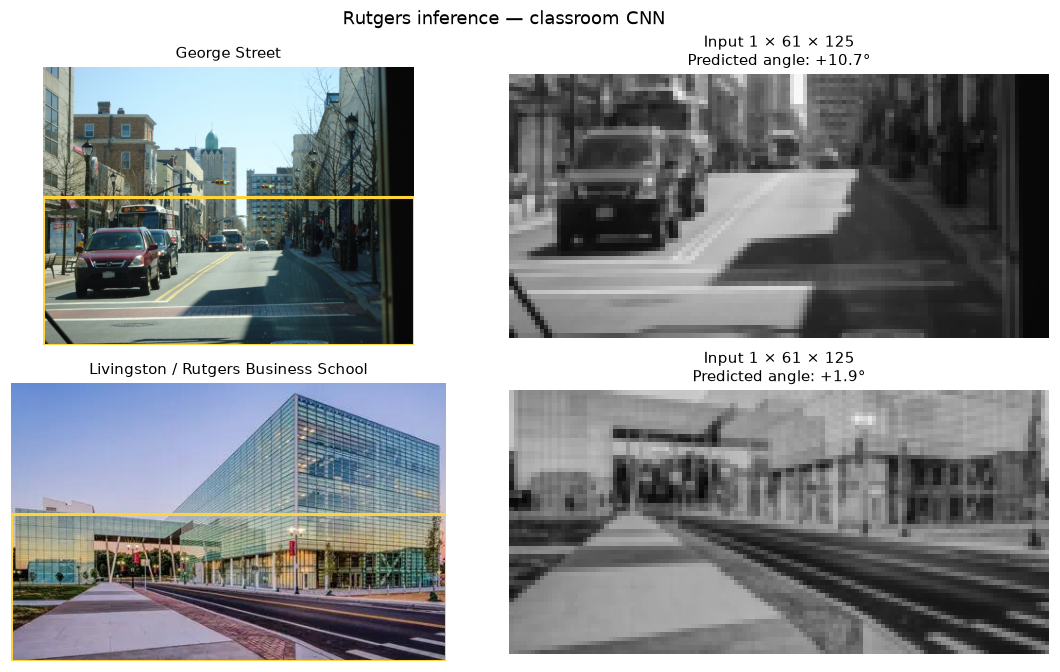

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout='constrained')
for row, (source, photo, prepared) in enumerate(zip(CAMPUS_SOURCES, campus_photos, campus_preprocessed)):
    x0, y0, x1, y1 = prepared[2]
    axes[row, 0].imshow(photo)
    axes[row, 0].add_patch(Rectangle((x0,y0), x1-x0, y1-y0, fill=False, ec='#ffd43b', lw=2))
    axes[row, 0].set_title(source['name'], fontsize=10)
    axes[row, 1].imshow(campus_raw[row, 0], cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f'Input 1 × 61 × 125\nPredicted angle: {campus_angles[row]:+.1f}°', fontsize=10)
    for ax in axes[row]:
        ax.axis('off')
fig.suptitle('Rutgers inference — classroom CNN')
plt.show()

## 4. Exercise 2 — Implement VisualBackProp (reference solution)
Average channels after each ReLU. Starting at the deepest map, upconvolve with an **all-ones kernel**,
multiply by the previous layer's average map, and repeat. Finally upconvolve to the input size and normalize.
This computation needs **no additional training and no gradients**; its mask is not a reconstruction of the image.

Source: Bojarski et al., [VisualBackProp, §III and Fig. 2, p. 4703](https://doi.org/10.1109/ICRA.2018.8461053).
The method uses strong deep responses to select regions and shallow responses to refine their locations;
the mask does not certify which pixels causally determine the final steering output.

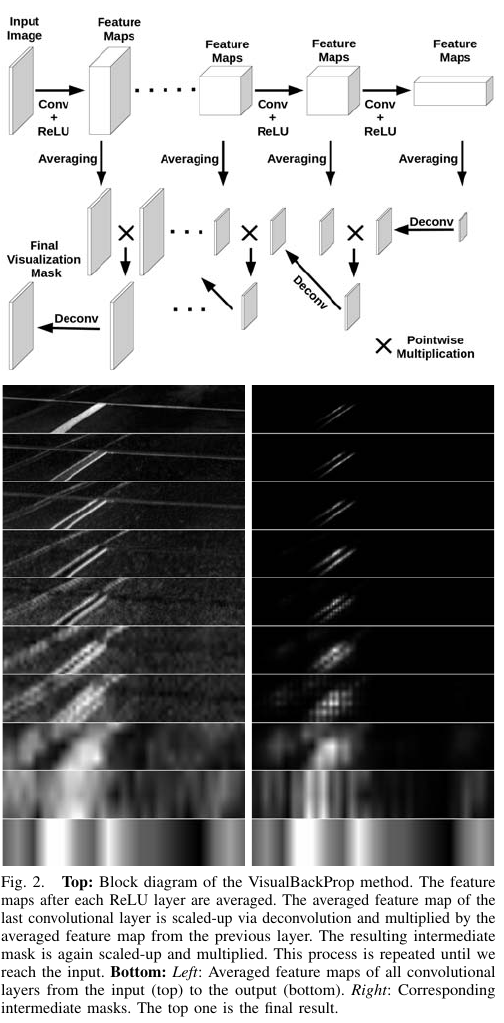

In [9]:
#@title Paper Fig. 2 — embedded figure (run to display)
display(DisplayImage(data=base64.b64decode("..."), width=470))

*Fig. 2, cropped from Bojarski et al., ICRA 2018, p. 4703. Top: the algorithm; bottom: average feature maps and intermediate masks.*

For dilation 1, the transposed-convolution output size is
$$O'=(N'-1)S-2P+K+\text{output\_padding}.$$
Our CNN has $P=0$, and every reverse step fits with `output_padding=0`.
Each input to upconvolution is `(B,1,H,W)` and its ones-kernel has shape `(1,1,3,3)`.
[PyTorch ConvTranspose2d: Shape / Notes](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html).

| Reverse layer | S | Small map → target size | Multiply by |
|---|---:|---|---|
| Conv6 | 2 | 5 × 13 → 11 × 27 | Average of Conv5 |
| Conv5 | 1 | 11 × 27 → 13 × 29 | Average of Conv4 |
| Conv4 | 2 | 13 × 29 → 27 × 59 | Average of Conv3 |
| Conv3 | 1 | 27 × 59 → 29 × 61 | Average of Conv2 |
| Conv2 | 2 | 29 × 61 → 59 × 123 | Average of Conv1 |
| Conv1 | 1 | 59 × 123 → 61 × 125 | Nothing; normalize |

In [10]:
# Exercise 2 — complete instructor solution, including the upconvolution call.
@torch.no_grad()
def visual_backprop(model, x, return_steps=False):
    # Preserve all module train/eval flags, including deliberately mixed states.
    modes = [(module, module.training) for module in model.modules()]
    model.eval()
    try:
        _, maps = model(x, return_maps=True)
        averages = [feature.mean(dim=1, keepdim=True) for feature in maps]
        mask = averages[-1]
        steps = [mask]  # deepest map first; final element will have the input size
        for i in range(len(averages) - 1, -1, -1):
            conv = model.convs[i]
            kernel = mask.new_ones((1, 1, *conv.kernel_size))
            # bias=None is zero bias; these kernel values are fixed, not learned.
            target_hw = averages[i-1].shape[-2:] if i > 0 else x.shape[-2:]
            mask = F.conv_transpose2d(mask, kernel, bias=None, stride=conv.stride,
                                      padding=conv.padding, output_padding=0)
            assert mask.shape[-2:] == target_hw, 'Reverse step does not match the forward input size.'
            if i > 0:
                mask = mask * averages[i-1]
            steps.append(mask)
        lo = mask.amin(dim=(-2, -1), keepdim=True)
        hi = mask.amax(dim=(-2, -1), keepdim=True)
        span = hi - lo
        denominator = torch.where(span > 0, span, torch.ones_like(span))
        mask = (mask - lo) / denominator  # a constant (including all-zero) map becomes zero
        return (mask, steps) if return_steps else mask
    finally:
        for module, was_training in modes:
            module.training = was_training

In [11]:
# A hand-checkable overlap example: each value stamps a 2 × 2 block.
small = torch.tensor([[[[1., 2.]]]])
up = F.conv_transpose2d(small, torch.ones(1, 1, 2, 2))
assert torch.equal(up[0, 0], torch.tensor([[1., 3., 2.], [1., 3., 2.]]))
print('Two overlapping stamps:\n', up[0, 0])
check_x = example_x[:2].to(device)
check_mask = visual_backprop(model, check_x)
assert check_mask.shape == (2, 1, IMG_H, IMG_W)
assert torch.isfinite(check_mask).all() and check_mask.min() >= 0 and check_mask.max() <= 1
assert not check_mask.requires_grad
print('PASS: mask shape', tuple(check_mask.shape), '| finite values in [0, 1] | no gradient graph.')

Two overlapping stamps:
 tensor([[1., 3., 2.],
        [1., 3., 2.]])
PASS: mask shape (2, 1, 61, 125) | finite values in [0, 1] | no gradient graph.


## 5. Inspect the driving examples
Compare the same six held-out inputs before training and at the validation-selected checkpoint.
Each heatmap is followed by its overlay. Green indicates larger **normalized mask values**, not confidence.
A short-trained model may highlight background as well as road features.
The additional contact sheet shows all 12 validation frames fixed before these data experiments, including failures.

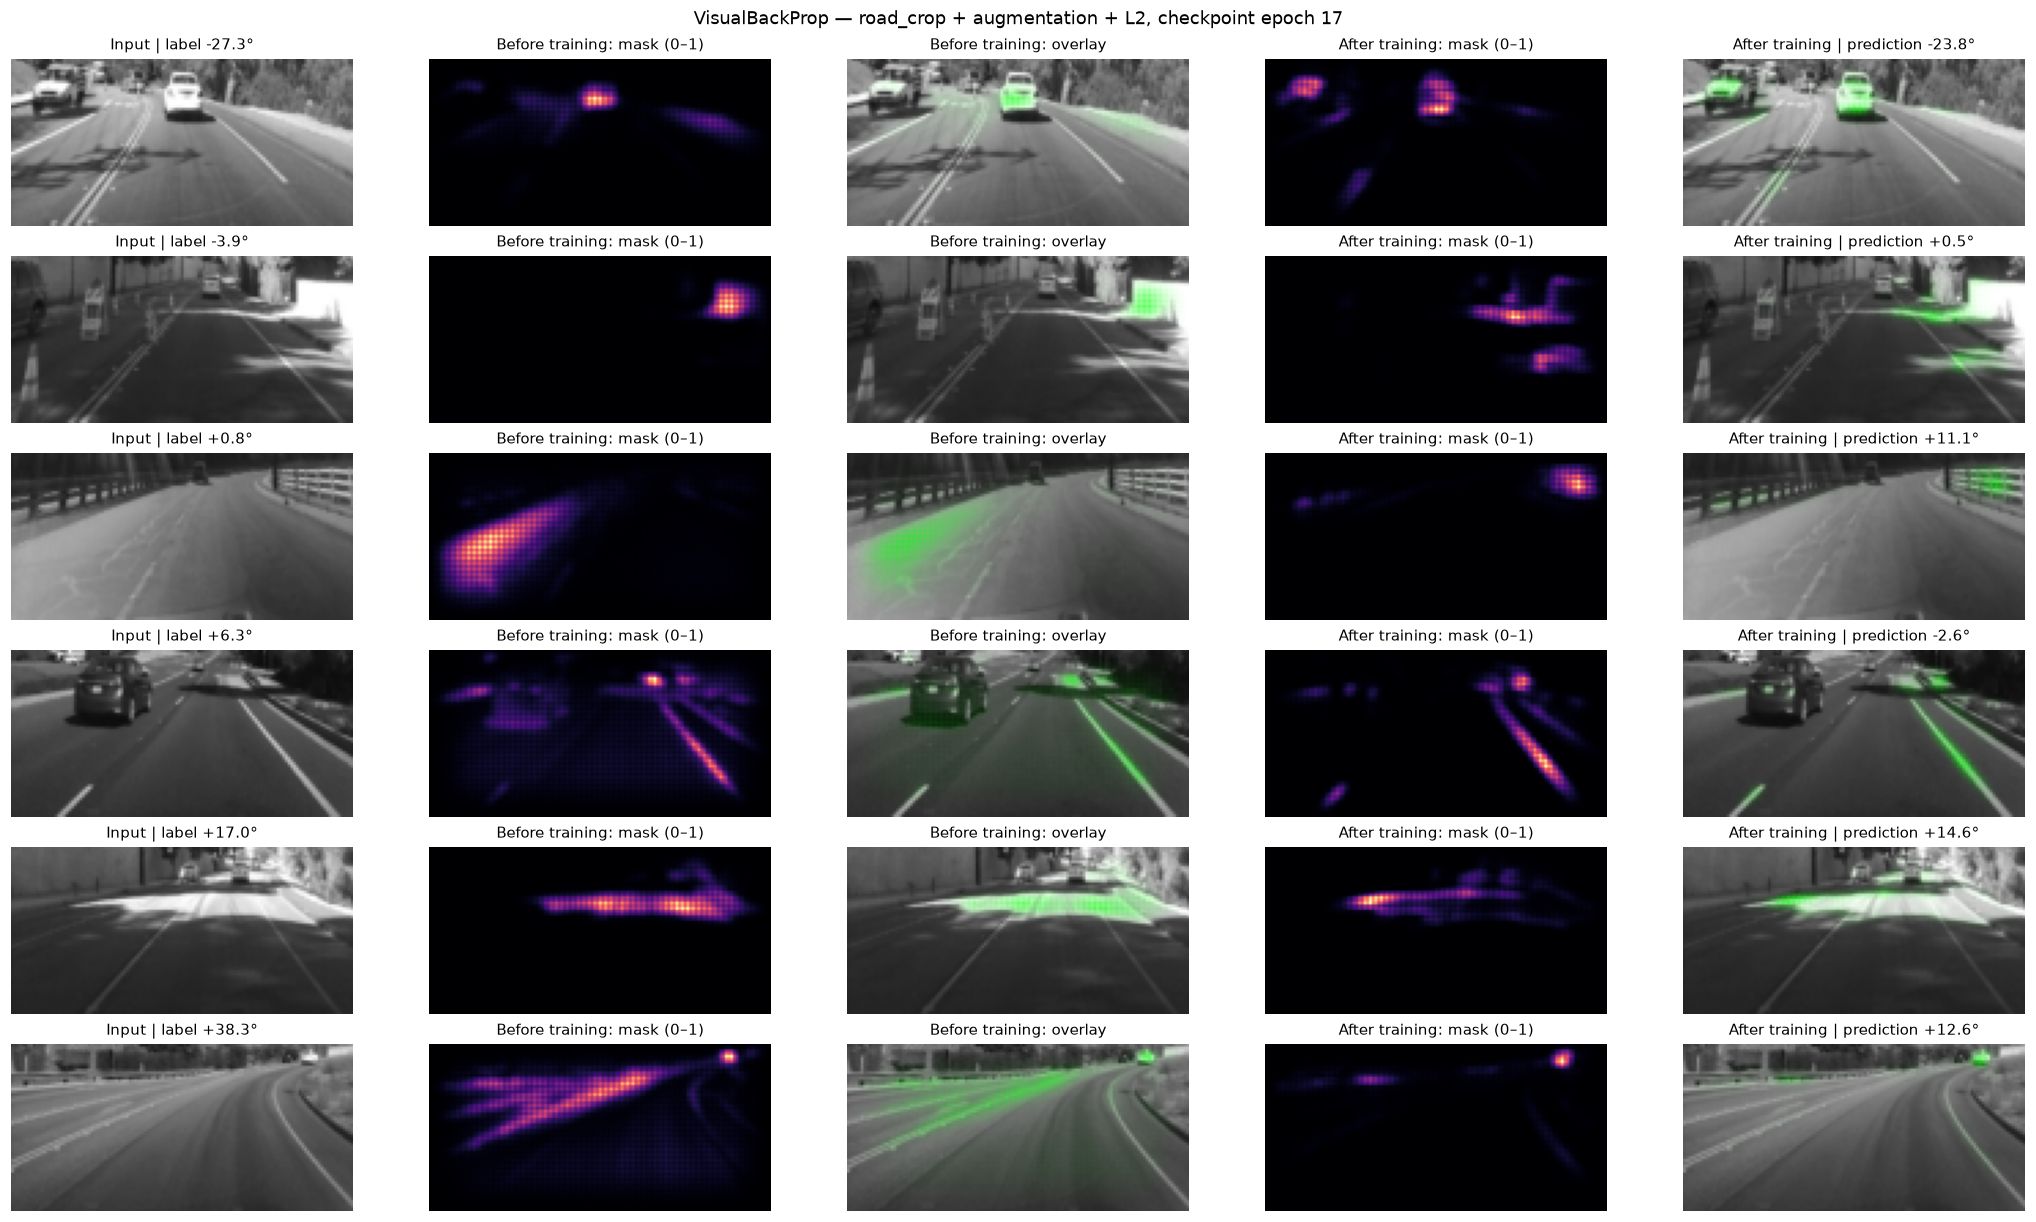

In [12]:
# Display helpers use the unstandardized [0, 1] images.
def draw_input(ax, raw, title):
    ax.imshow(raw, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def draw_mask(ax, mask, title):
    ax.imshow(mask, cmap='magma', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def draw_overlay(ax, raw, mask, title):
    draw_input(ax, raw, title)
    green = np.zeros((*mask.shape, 4), dtype=np.float32)
    green[..., 1] = 1.0
    green[..., 3] = 0.65 * mask  # a zero mask leaves the input unchanged
    ax.imshow(green)

example_batch = example_x.to(device)
before_masks = visual_backprop(untrained_model, example_batch).cpu()
after_masks = visual_backprop(model, example_batch).cpu()
with torch.no_grad():
    example_predictions = (60 * model(example_batch)).cpu()
fig, axes = plt.subplots(6, 5, figsize=(19, 11), layout='constrained')
for row in range(6):
    raw = example_raw[row, 0].numpy()
    before, after = before_masks[row, 0].numpy(), after_masks[row, 0].numpy()
    draw_input(axes[row, 0], raw, f'Input | label {example_angles[row]:+.1f}°')
    draw_mask(axes[row, 1], before, 'Before training: mask (0–1)')
    draw_overlay(axes[row, 2], raw, before, 'Before training: overlay')
    draw_mask(axes[row, 3], after, 'After training: mask (0–1)')
    draw_overlay(axes[row, 4], raw, after,
                 f'After training | prediction {example_predictions[row]:+.1f}°')
fig.suptitle(f'VisualBackProp — {RECIPE_NAME}, checkpoint epoch {best_epoch}')
plt.show()

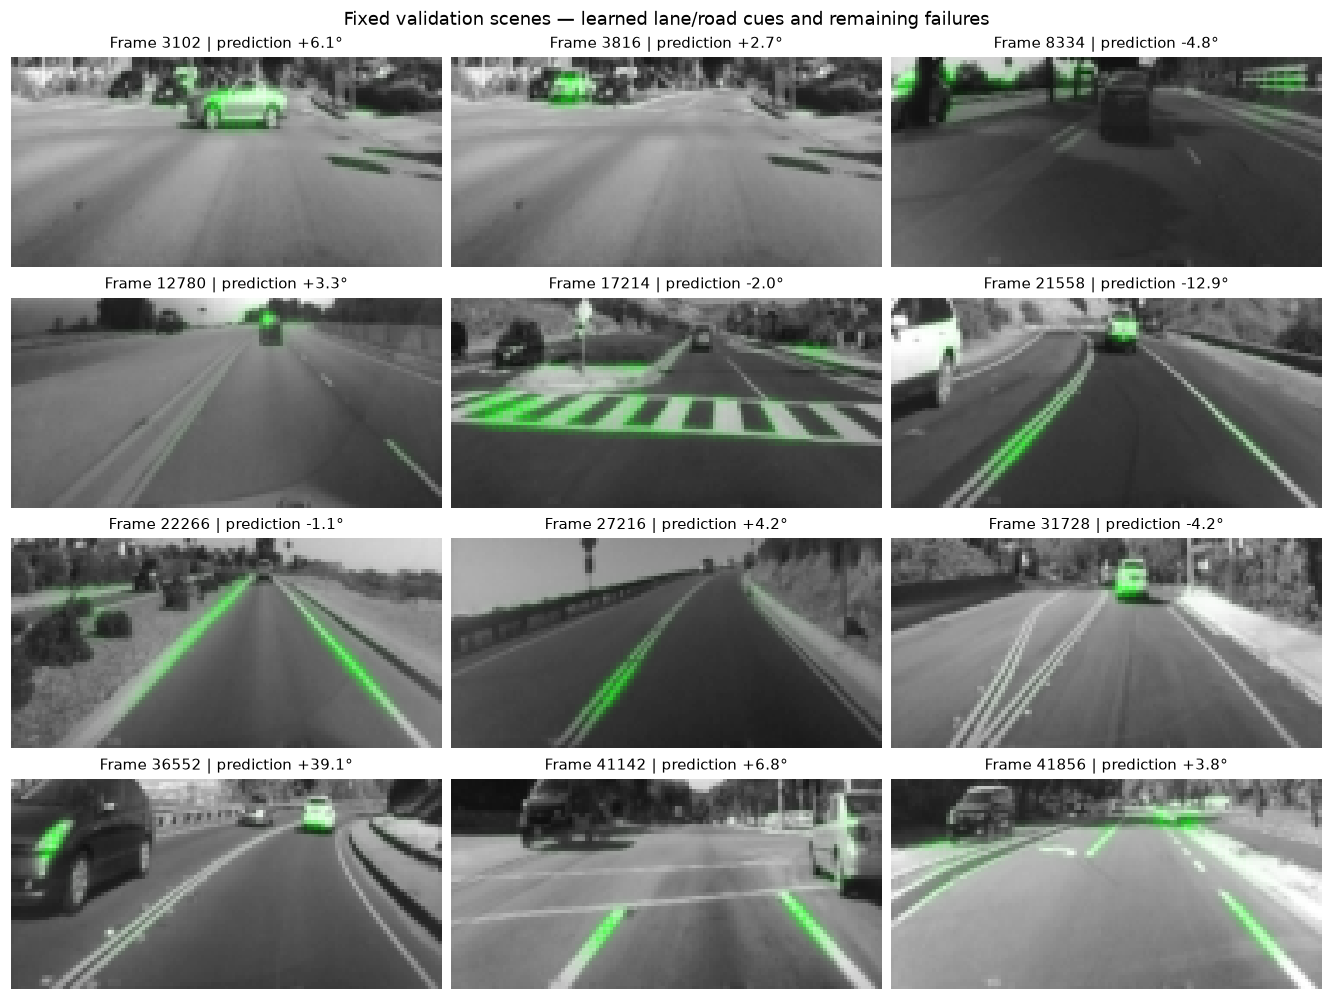

In [13]:
# Provided diagnostic: all 12 validation scenes fixed before the data experiments.
validation_indices = np.searchsorted(frames, data['visualization_frames'])
assert np.array_equal(frames[validation_indices], data['visualization_frames'])
assert bool(is_val[validation_indices].all())
validation_raw = images[validation_indices]
validation_x = ((validation_raw - train_mean) / train_std).to(device)
validation_masks = visual_backprop(model, validation_x).cpu()
with torch.no_grad():
    validation_angles = (60 * model(validation_x)).cpu()
fig, axes = plt.subplots(4, 3, figsize=(12, 9), layout='constrained')
for i, ax in enumerate(axes.flat):
    draw_overlay(ax, validation_raw[i, 0].numpy(), validation_masks[i, 0].numpy(),
                 f'Frame {frames[validation_indices[i]]} | prediction {validation_angles[i]:+.1f}°')
fig.suptitle('Fixed validation scenes — learned lane/road cues and remaining failures')
plt.show()

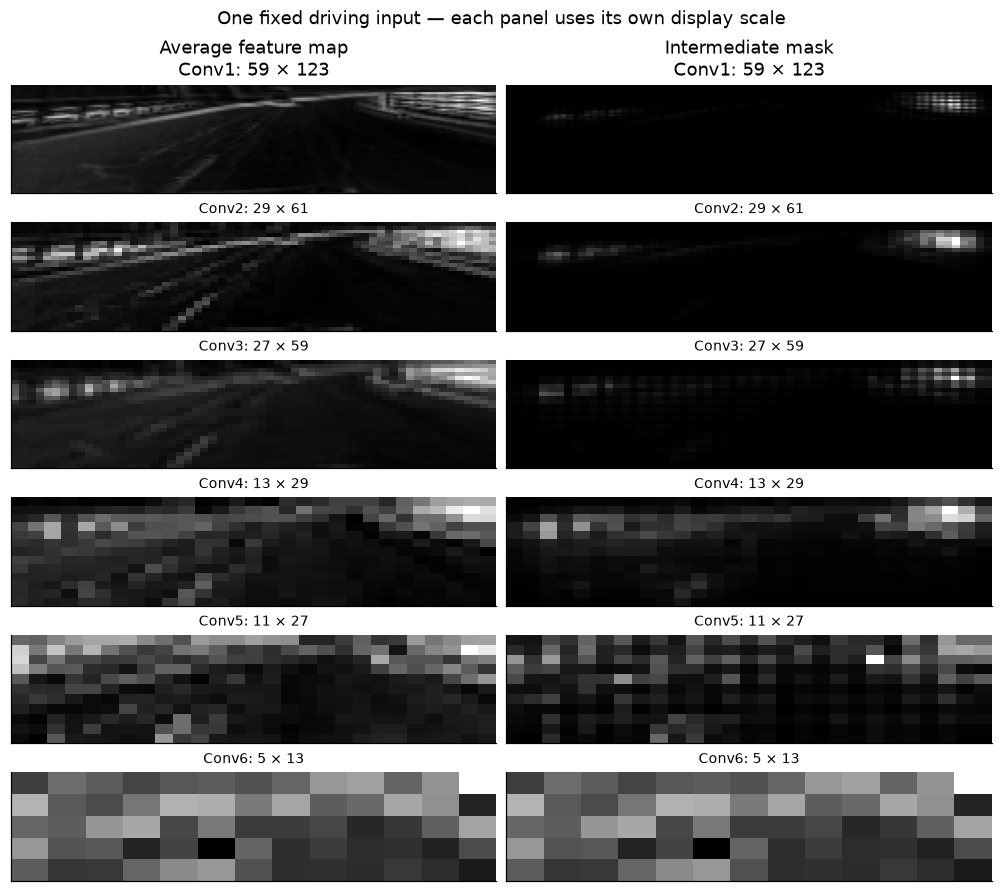

In [14]:
# Trace a fixed example through all six layers, shallow to deep (as in paper Fig. 2).
trace_x = example_batch[2:3]
with torch.no_grad():
    _, feature_maps = model(trace_x, return_maps=True)
_, steps = visual_backprop(model, trace_x, return_steps=True)
layer_masks = steps[:-1][::-1]  # omit the final input-size map, then reverse to shallow -> deep
fig, axes = plt.subplots(6, 2, figsize=(9, 8), layout='constrained')
for row, (feature, layer_mask) in enumerate(zip(feature_maps, layer_masks)):
    average = feature.mean(dim=1)[0].cpu().numpy()
    for col, arr in enumerate((average, layer_mask[0, 0].cpu().numpy())):
        axes[row, col].imshow(arr, cmap='gray', aspect='auto')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        axes[row, col].set_title(f'Conv{row+1}: {arr.shape[0]} × {arr.shape[1]}', fontsize=9)
axes[0, 0].set_title('Average feature map\n' + axes[0, 0].get_title())
axes[0, 1].set_title('Intermediate mask\n' + axes[0, 1].get_title())
fig.suptitle('One fixed driving input — each panel uses its own display scale')
plt.show()

## 6. Back to Rutgers: what does this model highlight?
Reuse the **same preprocessed campus batch** and trained model from Part 3. The masks align with the cropped
network inputs, not with the full original photographs.

Photo credits: George Street — Tomwsulcer, [Wikimedia Commons, CC0](https://commons.wikimedia.org/wiki/File:Rutgers_University_New_Brunswick_downtown_George_Street_view_street_scene.jpg);
Livingston — [Rutgers Business School](https://www.business.rutgers.edu/visit/livingston-highlights).

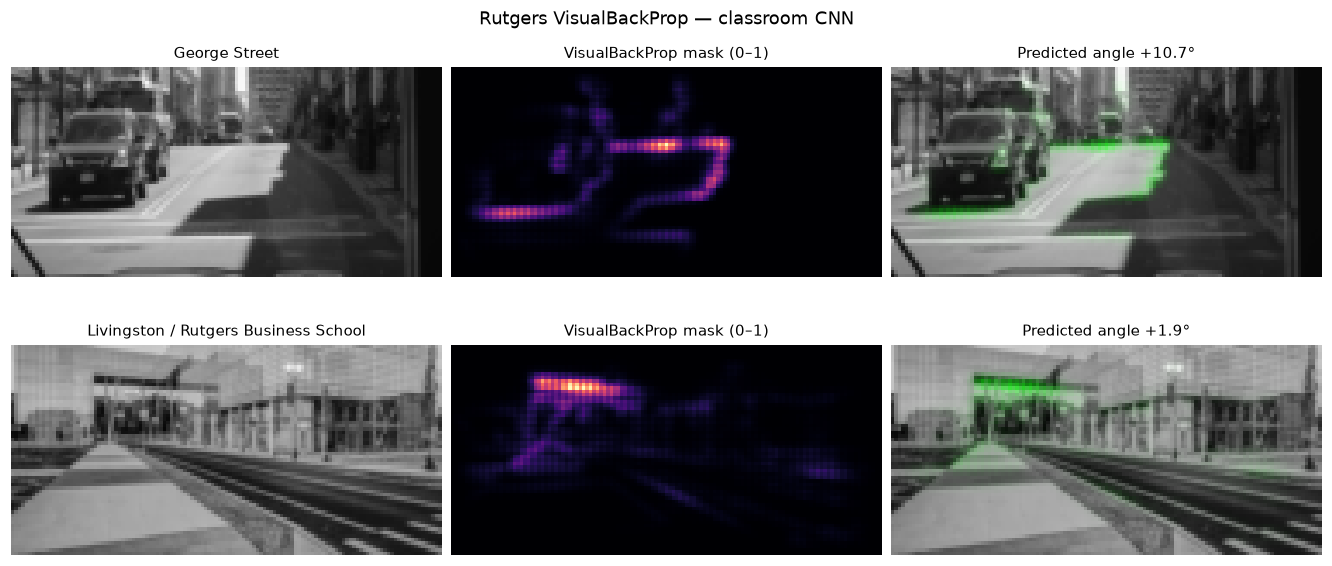

In [15]:
campus_masks = visual_backprop(model, campus_x).cpu()
fig, axes = plt.subplots(2, 3, figsize=(12, 5.3), layout='constrained')
for row, source in enumerate(CAMPUS_SOURCES):
    raw, mask = campus_raw[row, 0].numpy(), campus_masks[row, 0].numpy()
    draw_input(axes[row, 0], raw, source['name'])
    draw_mask(axes[row, 1], mask, 'VisualBackProp mask (0–1)')
    draw_overlay(axes[row, 2], raw, mask, f'Predicted angle {campus_angles[row]:+.1f}°')
fig.suptitle('Rutgers VisualBackProp — classroom CNN')
plt.show()

### Sources
- Bojarski et al., *VisualBackProp*, ICRA 2018: [§III / Fig. 2, p. 4703](https://doi.org/10.1109/ICRA.2018.8461053).
- PyTorch: [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html),
  [ConvTranspose2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html).
- Araujo et al., [Computing Receptive Fields of Convolutional Neural Networks](https://distill.pub/2019/computing-receptive-fields/), section “Computing receptive field size”.
- Driving data and the two campus-photo sources are credited next to their figures above.
- Validation and train-only preprocessing: [scikit-learn, Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).